# Notebook Kelompok 10
## Tugas Data Mining I TM12

### Import Library

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import geopandas as gpd
from scipy import stats
from scipy.stats import gaussian_kde
from scipy.cluster.hierarchy import linkage, dendrogram
import squarify 
import warnings
warnings.filterwarnings('ignore')

### Import Dataset

In [3]:
data = pd.read_excel("C:/Uner/Semester 4/Data Mining I/Week 11/Tugas Kelompok 10/Data.xlsx")

### Informasi Dataset

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Provinsi                        34 non-null     object 
 1   PDB_perkapita                   34 non-null     float64
 2   Laju_pertumbuhan_PDB_perkapita  34 non-null     float64
 3   Upah_ratarata_perjam            34 non-null     float64
 4   Tingkat_pengganguran            34 non-null     float64
 5   Tingkat_setengah_pengangguran   34 non-null     float64
 6   Proporsi_kerja_informal         34 non-null     float64
 7   Usia_muda_neet                  34 non-null     float64
dtypes: float64(7), object(1)
memory usage: 2.3+ KB


### Missing Value Dataset

In [5]:
print("\nJumlah Missing Value Tiap Kolom:\n", data.isnull().sum())



Jumlah Missing Value Tiap Kolom:
 Provinsi                          0
PDB_perkapita                     0
Laju_pertumbuhan_PDB_perkapita    0
Upah_ratarata_perjam              0
Tingkat_pengganguran              0
Tingkat_setengah_pengangguran     0
Proporsi_kerja_informal           0
Usia_muda_neet                    0
dtype: int64


In [6]:
numeric_cols = data.select_dtypes(include=np.number).columns.tolist()

### Statistika Deskptif Dataset

In [7]:
print("\nStatistika Deskriptif:")
print(data[numeric_cols].describe())


Statistika Deskriptif:
       PDB_perkapita  Laju_pertumbuhan_PDB_perkapita  Upah_ratarata_perjam  \
count      34.000000                       34.000000             34.000000   
mean       76.521088                        4.330588             17.901471   
std        60.445160                        3.659343              4.181441   
min        21.718000                       -0.280000             11.734000   
25%        44.316000                        3.030000             15.320000   
50%        59.227500                        3.670000             16.931500   
75%        71.793250                        4.397500             18.943750   
max       298.360000                       21.060000             32.685000   

       Tingkat_pengganguran  Tingkat_setengah_pengangguran  \
count             34.000000                      34.000000   
mean               4.966176                       7.256176   
std                1.600225                       2.763056   
min                2.3400

### Outlier pada Dataset

In [8]:
def detect_plot_label_outliers(df, numeric_columns, label_column='Provinsi'):
    outlier_summary = {}  
    outlier_provinces = {} 

    for col in numeric_columns:
        df_col = df[[label_column, col]].dropna()

        Q1 = df_col[col].quantile(0.25)
        Q3 = df_col[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outlier_rows = df_col[(df_col[col] < lower) | (df_col[col] > upper)]
        outlier_summary[col] = outlier_rows.shape[0]
        outlier_provinces[col] = outlier_rows[label_column].tolist()

        plt.figure(figsize=(10, 4))
        sns.boxplot(x=col, data=df_col, color="#10375C", fliersize=5,
                    flierprops=dict(markerfacecolor='#F3C623', marker='o'))

        for i, row in outlier_rows.iterrows():
            plt.text(row[col], 0, row[label_column], fontsize=8, ha='center', va='bottom', rotation=90, color='#F3C623')

        plt.title(f'Boxplot & Outlier Label: {col} ({outlier_rows.shape[0]} provinsi)', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

    return outlier_summary, outlier_provinces


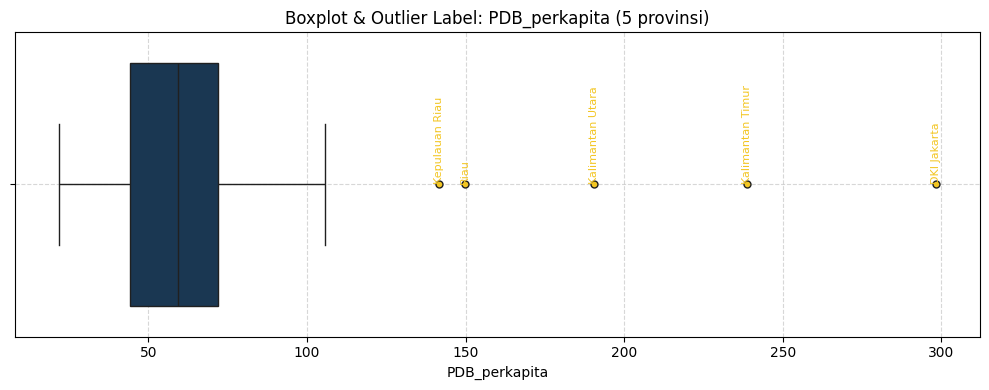

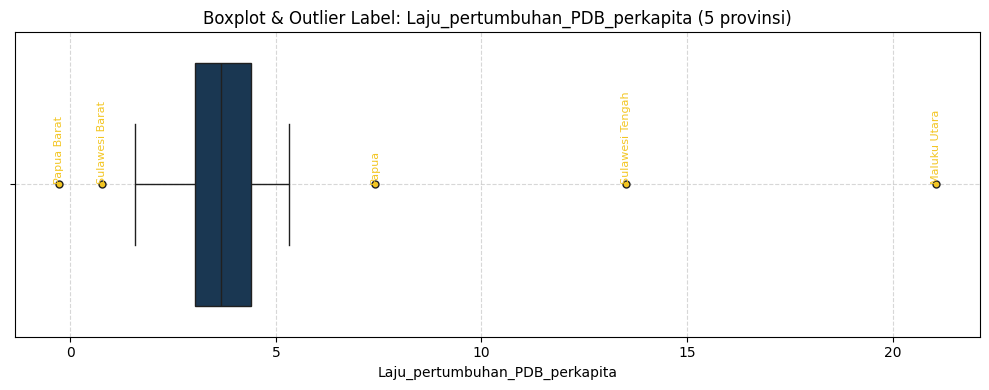

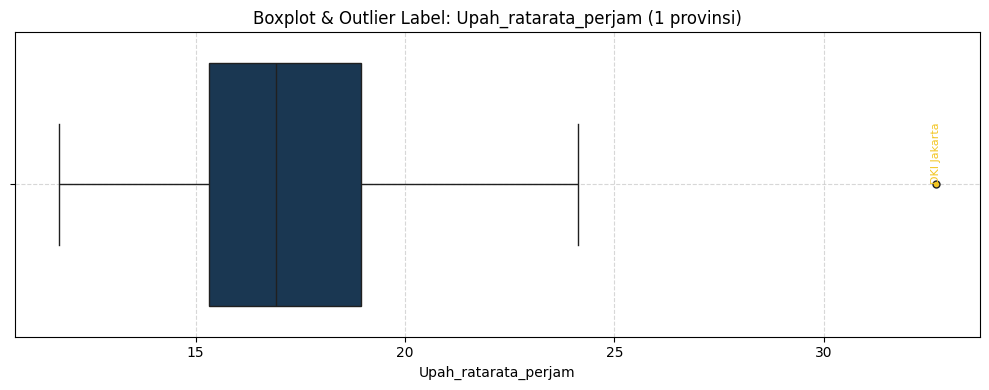

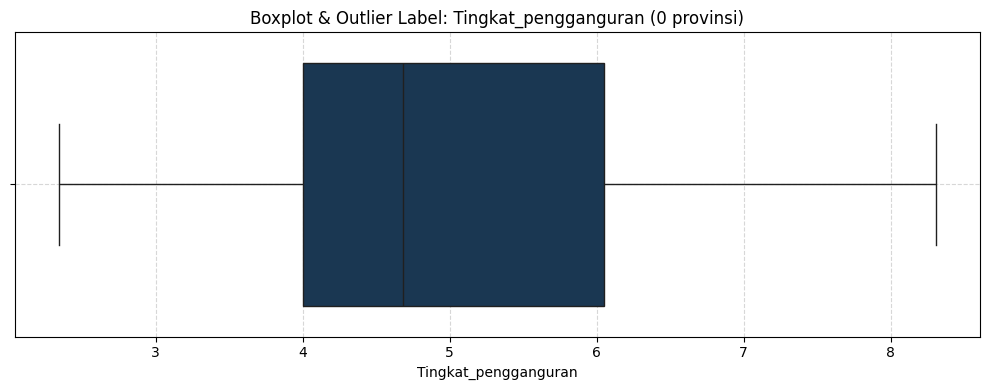

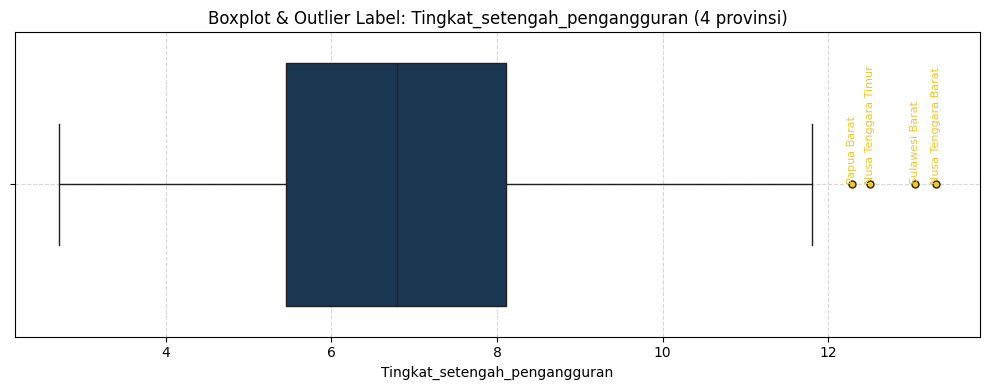

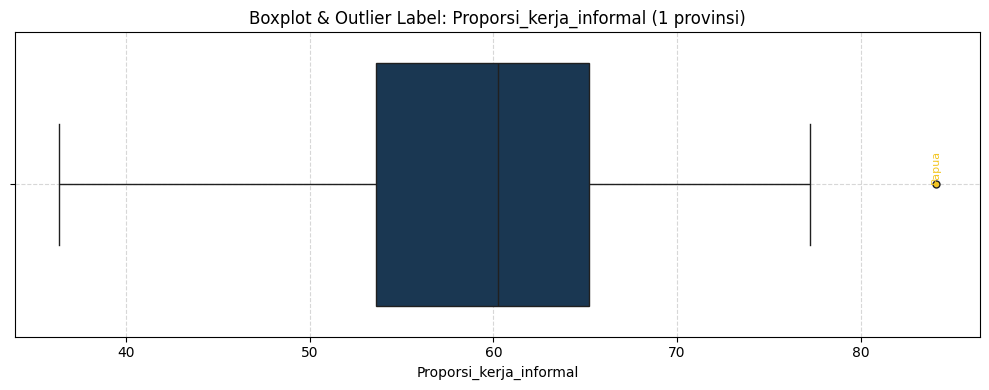

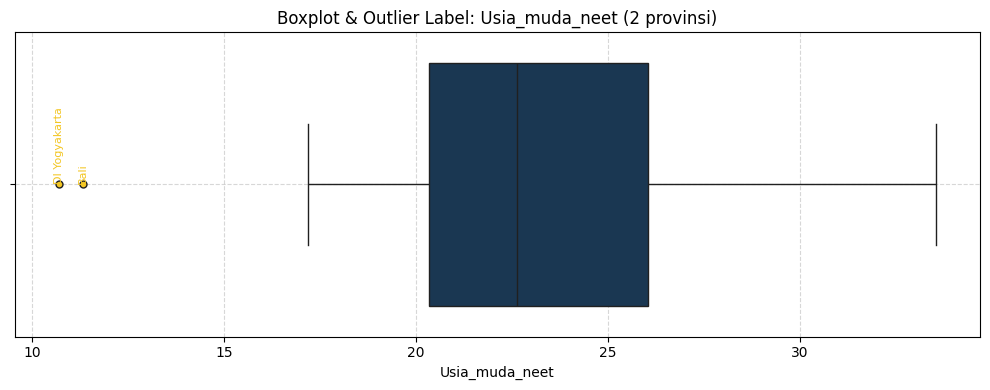


Jumlah dan Nama Provinsi Outlier:

PDB_perkapita - Total: 5
Provinsi: Riau, Kepulauan Riau, DKI Jakarta, Kalimantan Timur, Kalimantan Utara

Laju_pertumbuhan_PDB_perkapita - Total: 5
Provinsi: Sulawesi Tengah, Sulawesi Barat, Maluku Utara, Papua Barat, Papua

Upah_ratarata_perjam - Total: 1
Provinsi: DKI Jakarta

Tingkat_pengganguran - Total: 0
Provinsi: -

Tingkat_setengah_pengangguran - Total: 4
Provinsi: Nusa Tenggara Barat, Nusa Tenggara Timur, Sulawesi Barat, Papua Barat

Proporsi_kerja_informal - Total: 1
Provinsi: Papua

Usia_muda_neet - Total: 2
Provinsi: DI Yogyakarta, Bali


In [9]:
numeric_cols = data.select_dtypes(include='number').columns.tolist()
outlier_count, outlier_names = detect_plot_label_outliers(data, numeric_cols)

print("\nJumlah dan Nama Provinsi Outlier:")
for col in numeric_cols:
    print(f"\n{col} - Total: {outlier_count[col]}")
    print("Provinsi:", ", ".join(outlier_names[col]) if outlier_names[col] else "-")

### Distribusi Setiap Variabel Pada Dataset

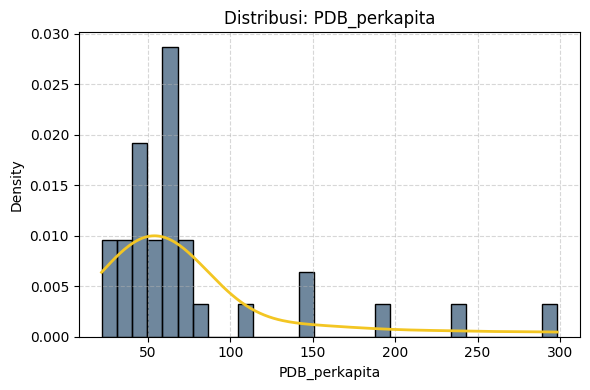

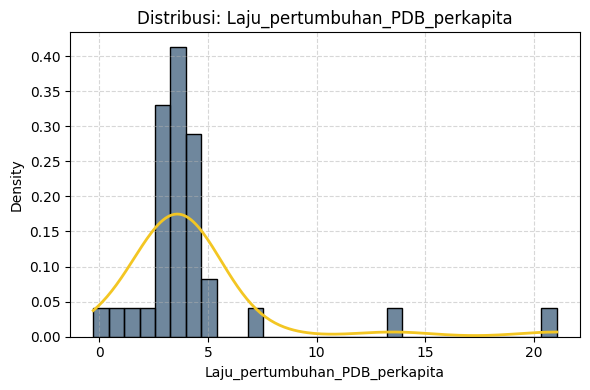

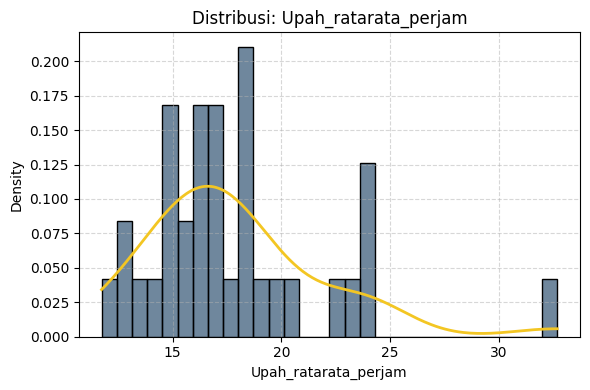

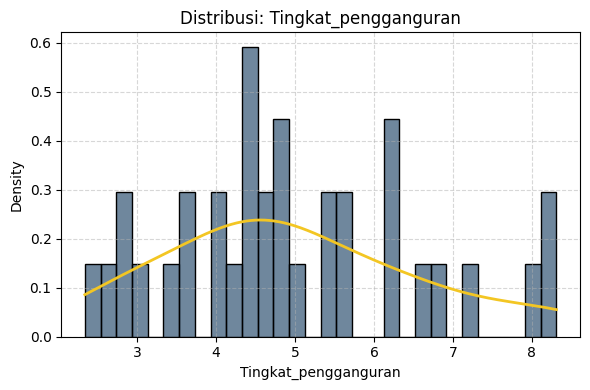

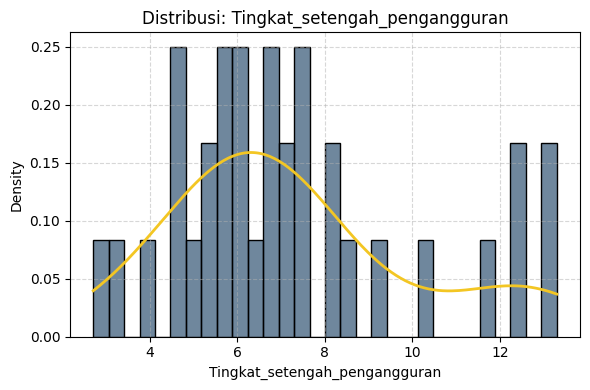

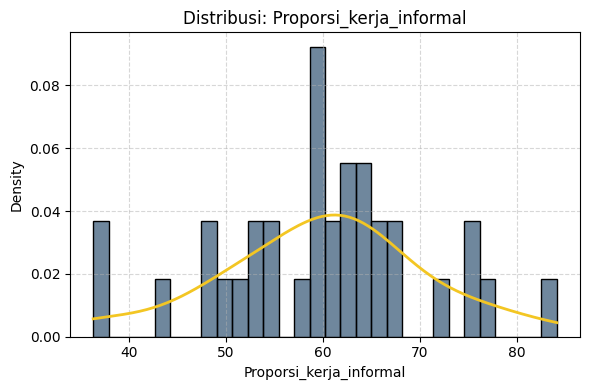

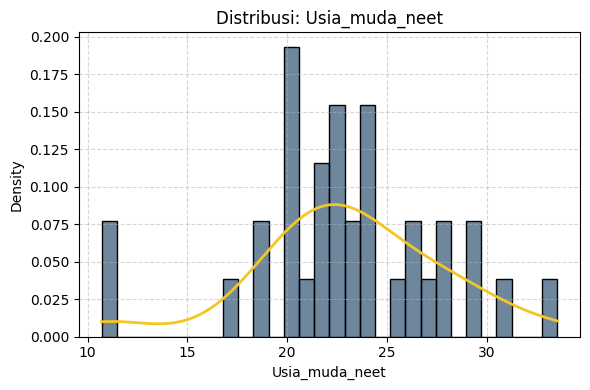

In [10]:
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
   
    sns.histplot(data[col], stat='density', bins=30, color='#10375C', alpha=0.6)

    x = data[col].dropna()
    kde = gaussian_kde(x)
    x_vals = np.linspace(x.min(), x.max(), 200)
    plt.plot(x_vals, kde(x_vals), color='#F3C623', linewidth=2)

    plt.title(f'Distribusi: {col}', fontsize=12)
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

### Uji Normalitas Setiap Variabel

In [11]:
print("\nUji Normalitas (Shapiro-Wilk):")
for col in numeric_cols:
    stat, p = stats.shapiro(data[col].dropna())
    print(f"{col}: Statistik = {stat:.3f}, p-value = {p:.3f} → {'Normal' if p > 0.05 else 'Tidak Normal'}")



Uji Normalitas (Shapiro-Wilk):
PDB_perkapita: Statistik = 0.681, p-value = 0.000 → Tidak Normal
Laju_pertumbuhan_PDB_perkapita: Statistik = 0.586, p-value = 0.000 → Tidak Normal
Upah_ratarata_perjam: Statistik = 0.887, p-value = 0.002 → Tidak Normal
Tingkat_pengganguran: Statistik = 0.961, p-value = 0.258 → Normal
Tingkat_setengah_pengangguran: Statistik = 0.919, p-value = 0.015 → Tidak Normal
Proporsi_kerja_informal: Statistik = 0.980, p-value = 0.777 → Normal
Usia_muda_neet: Statistik = 0.962, p-value = 0.279 → Normal


### Heatmap Korelasi Antar Variabel

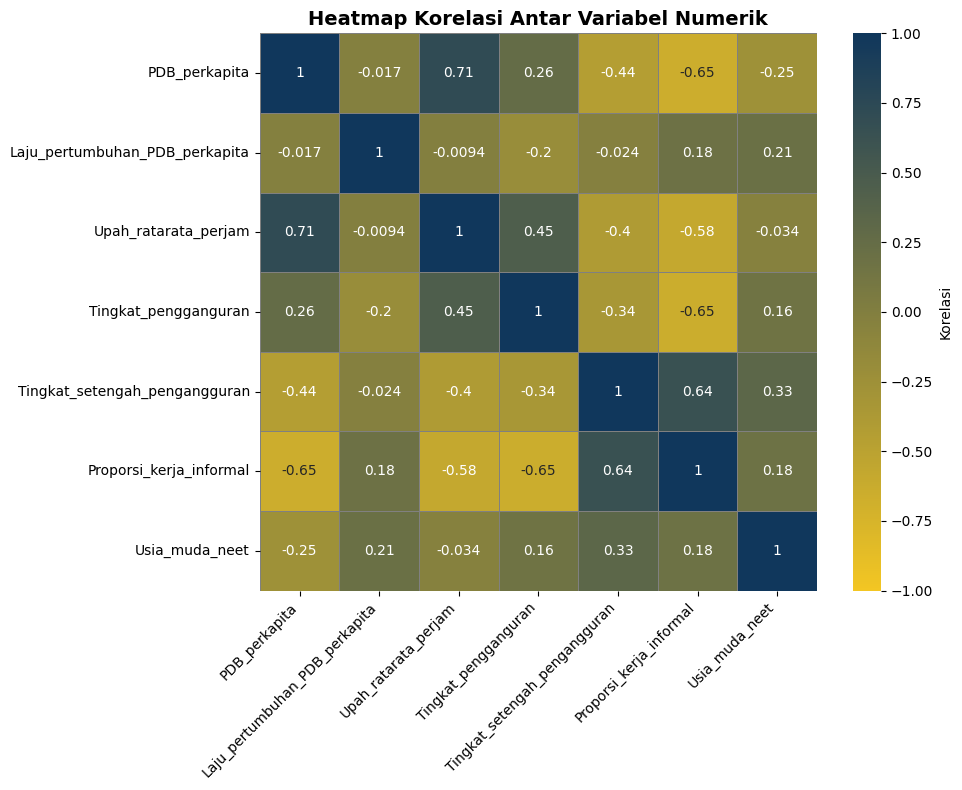

In [12]:
custom_cmap = LinearSegmentedColormap.from_list(
    "custom_blue_yellow", ['#F3C623', '#10375C']
)

plt.figure(figsize=(10, 8))
corr_matrix = data[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap=custom_cmap, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='gray', square=True, cbar_kws={'label': 'Korelasi'})

plt.title('Heatmap Korelasi Antar Variabel Numerik', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Visualisasi Distribusi Dataset Menggunakan Peta Tematik

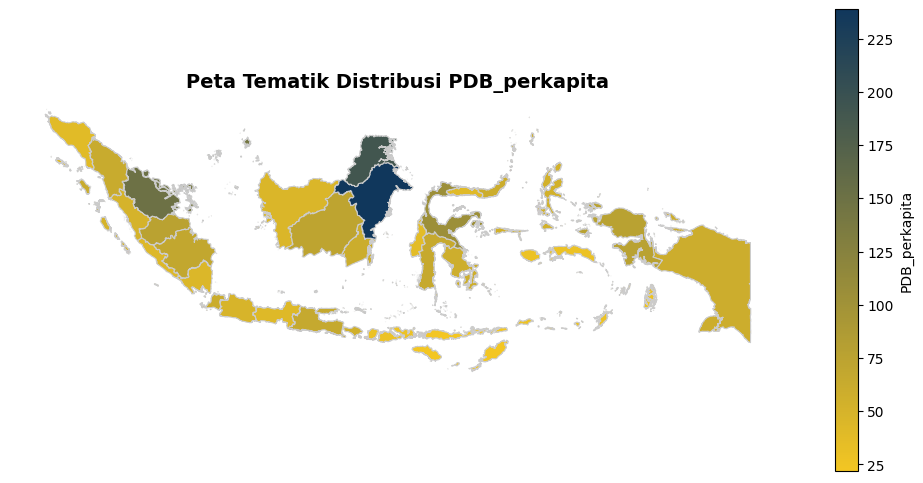

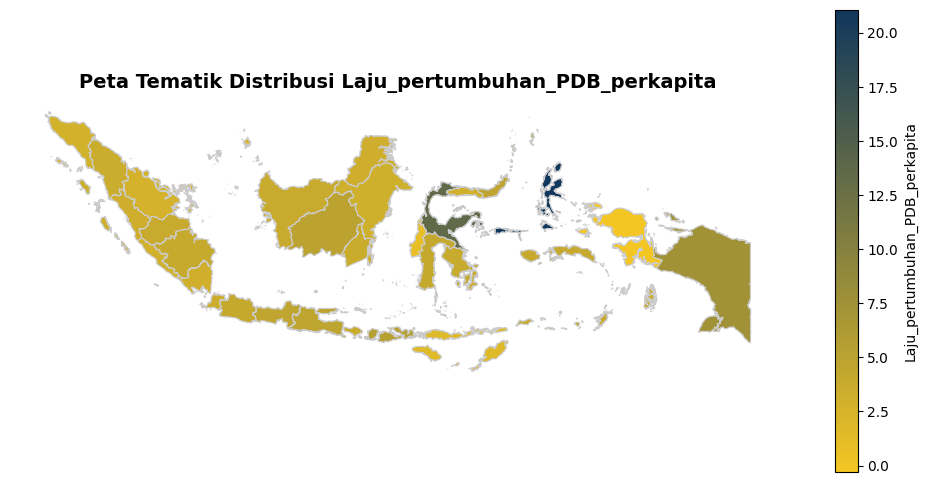

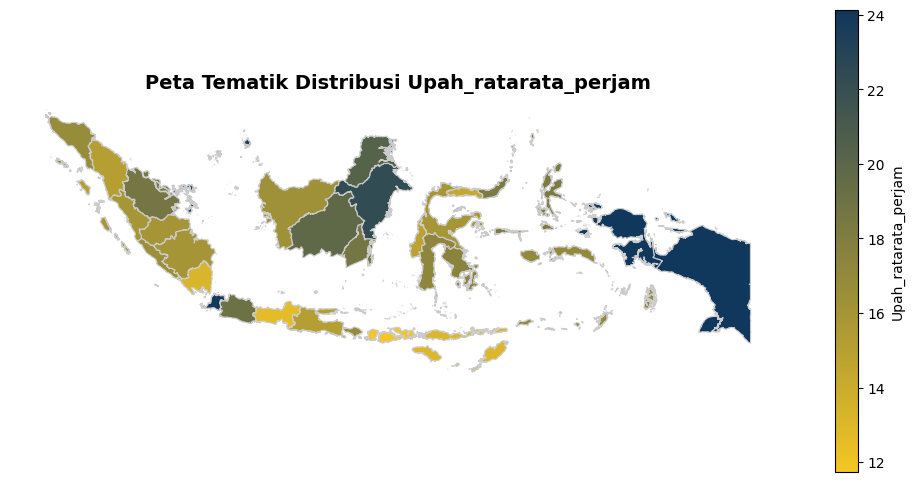

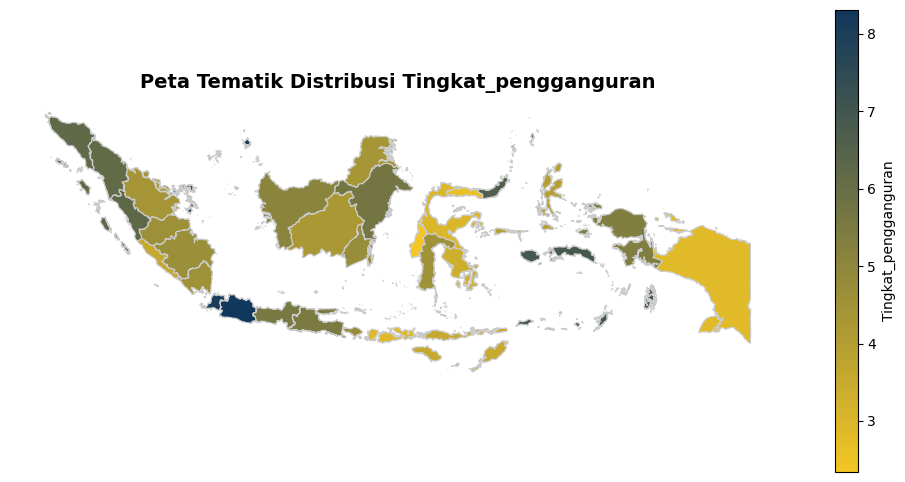

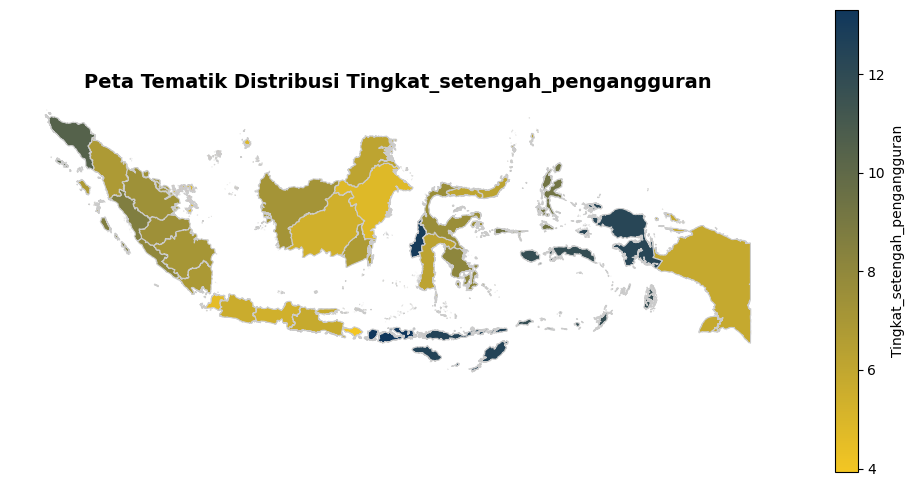

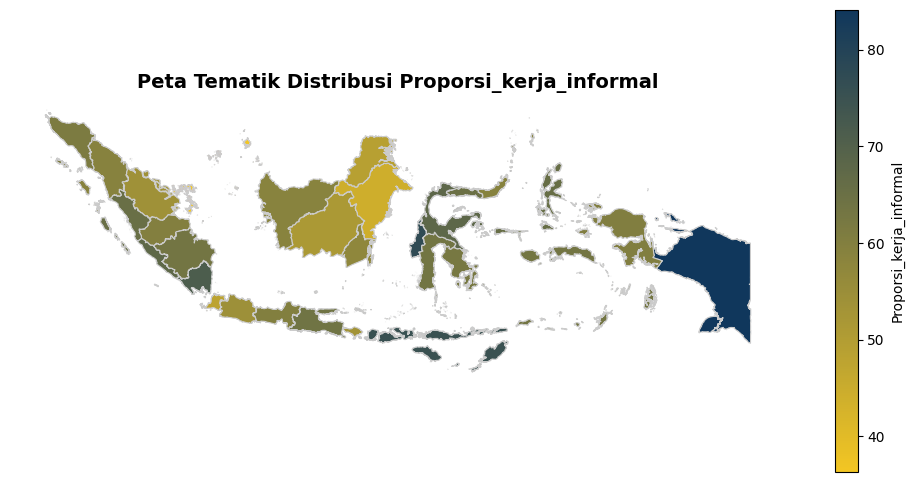

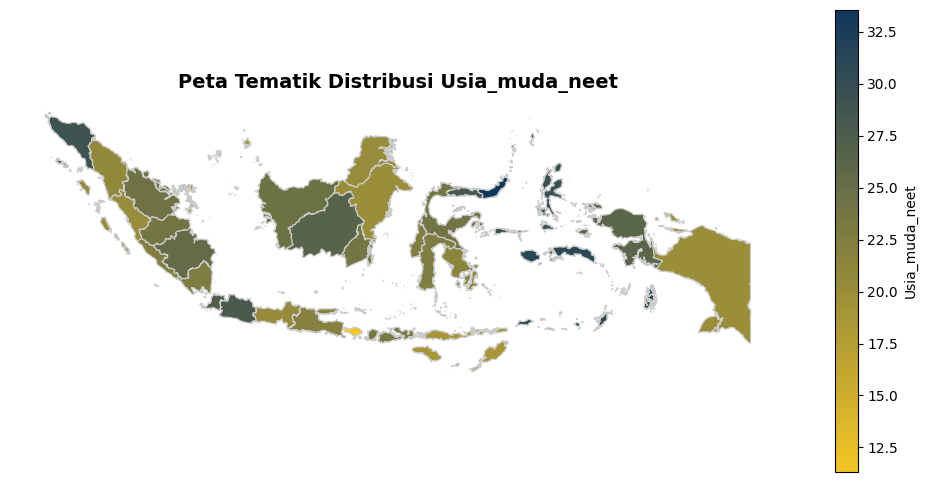

In [13]:
custom_cmap = LinearSegmentedColormap.from_list(
    "custom_map", ['#F3C623', '#10375C']
)

shapefile_path = "C:/Uner/Semester 4/Data Mining I/Week 11/Tugas Kelompok 10/gadm41_IDN_1.shp"

gdf = gpd.read_file(shapefile_path)

data['Provinsi'] = data['Provinsi'].str.title().str.strip()
gdf['Provinsi'] = gdf['NAME_1'].str.title().str.strip()

# Gabungkan GeoDataFrame dengan data
gdf_merged = gdf.merge(data, on='Provinsi')

for col in numeric_cols:
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    gdf_merged.plot(column=col,
                    cmap=custom_cmap,
                    linewidth=0.8,
                    edgecolor='0.8',
                    ax=ax,
                    legend=True,
                    legend_kwds={'label': col, 'shrink': 0.6})
    
    ax.set_title(f'Peta Tematik Distribusi {col}', fontdict={'fontsize': 14, 'fontweight': 'bold'})
    ax.axis('off')
    plt.tight_layout()
    plt.show()

### Clusetering Dataset Menggunakan Metode Single Linkage

In [14]:
from sklearn.preprocessing import StandardScaler

df_cluster = data[['Provinsi', 'PDB_perkapita']].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[['PDB_perkapita']])

linked = linkage(X_scaled, method='single')


### Visualisasi Clustering Menggunakan Dendogram

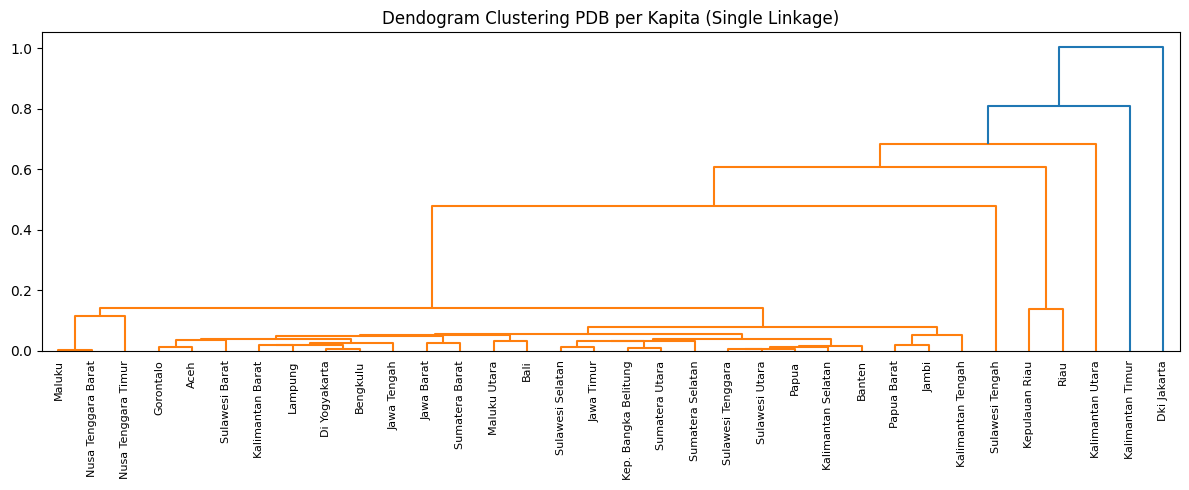

In [15]:
plt.figure(figsize=(12, 5))
dendrogram(linked,
           labels=df_cluster['Provinsi'].values,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Dendogram Clustering PDB per Kapita (Single Linkage)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


### Complete Linkage

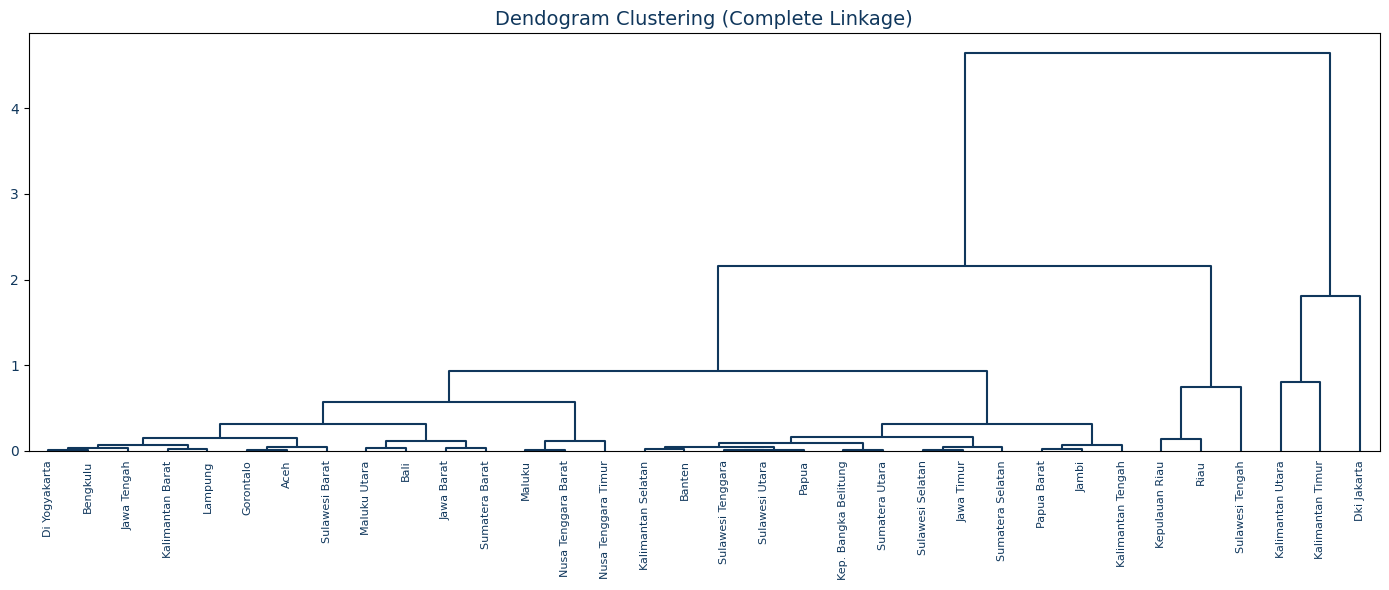

In [ ]:
linked_complete = linkage(X_scaled, method='complete')

plt.figure(figsize=(14, 6))
dendrogram(
    linked_complete,
    labels=df_cluster['Provinsi'].values,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=True,
    color_threshold=0,
    link_color_func=lambda k: '#10375C'
)
plt.title('Dendogram Clustering (Complete Linkage)', fontsize=14, color='#10375C')
plt.xticks(rotation=90, color='#10375C')
plt.yticks(color='#10375C')
plt.tight_layout()
plt.show()


### Avarage Linkage

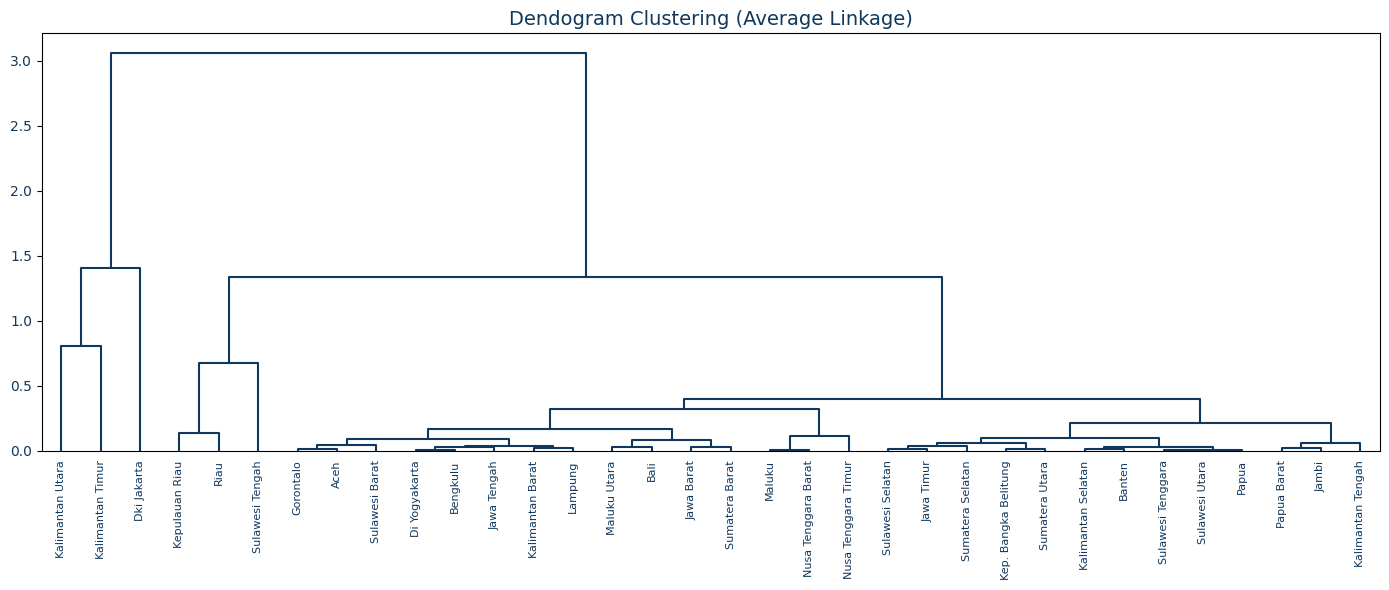

In [ ]:
linked_average = linkage(X_scaled, method='average')

plt.figure(figsize=(14, 6))
dendrogram(
    linked_average,
    labels=df_cluster['Provinsi'].values,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=True,
    color_threshold=0,
    link_color_func=lambda k: '#10375C'
)
plt.title('Dendogram Clustering (Average Linkage)', fontsize=14, color='#10375C')
plt.xticks(rotation=90, color='#10375C')
plt.yticks(color='#10375C')
plt.tight_layout()
plt.show()


### Evaluasi Metode Menggunakan Cophenetic Correlation Coefficient (CCC)

In [19]:
from scipy.cluster.hierarchy import cophenet
from scipy.spatial.distance import pdist

distances = pdist(X_scaled)

from scipy.stats import pearsonr

linked_single = linkage(X_scaled, method='single')
linked_complete = linkage(X_scaled, method='complete')
linked_average = linkage(X_scaled, method='average')

c_single, _ = cophenet(linked_single, distances)
c_complete, _ = cophenet(linked_complete, distances)
c_average, _ = cophenet(linked_average, distances)

print("Cophenetic Correlation Coefficient:")
print(f"- Single Linkage:   {c_single:.4f}")
print(f"- Complete Linkage: {c_complete:.4f}")
print(f"- Average Linkage:  {c_average:.4f}")

Cophenetic Correlation Coefficient:
- Single Linkage:   0.9319
- Complete Linkage: 0.9269
- Average Linkage:  0.9308


### Evaluasi Metode Menggunakan Analisis Silhouette Score

In [28]:
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import silhouette_score

n_clusters = 3

labels_single = fcluster(linked_single, n_clusters, criterion='maxclust')
labels_complete = fcluster(linked_complete, n_clusters, criterion='maxclust')
labels_average = fcluster(linked_average, n_clusters, criterion='maxclust')

score_single = silhouette_score(X_scaled, labels_single)
score_complete = silhouette_score(X_scaled, labels_complete)
score_average = silhouette_score(X_scaled, labels_average)

print("Silhouette Score (n=3):")
print(f"- Single Linkage:   {score_single:.4f}")
print(f"- Complete Linkage: {score_complete:.4f}")
print(f"- Average Linkage:  {score_average:.4f}")


Silhouette Score (n=3):
- Single Linkage:   0.7074
- Complete Linkage: 0.7156
- Average Linkage:  0.7304
